# Optimización Bayesiana

**Teorema de Bayes**

$$ P(A|B) = \frac{P(B|A) P(A)}{P(B)} $$

$ P(A|B) $: Probabilidad condicional de A dado B. También conocida como la probabilidad posterior de A dado que B ocurre.

$ P(B|A) $: Probabilidad condicional de B dado A. Se interpreta como la verosimilitud (*likelihood*) de A.

$ P(A) $: Probabilidad de observar A. También conocida como probabilidad a priori.

$ P(B) $: Probabilidad de observar B. Interpretada como evidencia.

Utilizando las definiciones de arriba actualizamos la definición del teorema de bayes:

$$ \text{posterior} = \frac{(\text{verosimilitud})(\text{anterior})}{\text{evidencia}} $$

La intuición es que el teorema de Bayes es una herramienta para actualizar nuestras creencias dado lo que se tenía antes y nueva evidencia. Por ejemplo, tomas una moneda y asumes que es una moneda justa, dado que es lo más probable y que las monedas suelen ser justas en tu experiencia. Lanzas la moneda tres veces y cae sello las tres veces; un poco extraño, así que ajustas tus creencias y empiezas a imaginar que la moneda no es tan justa como debería ser. Lanzas las monedas tres veces y cae águila; ahora crees que la moneda es justa de nuevo.

## ¿Cómo aplicamos esto en nuestra vida diaria?

Imagina que tienes 3 puntos (conocimiento previo) en un espacio.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler

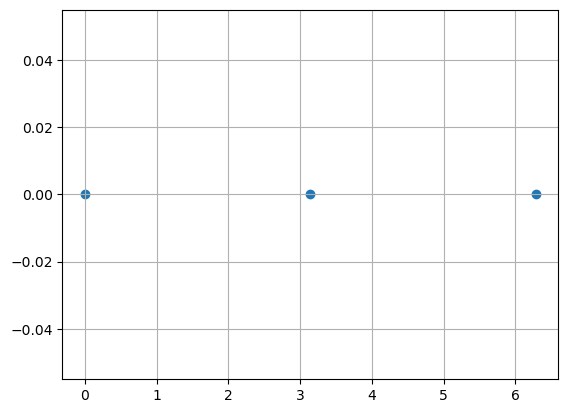

In [2]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(); plt.scatter([0, np.pi, 2*np.pi], [0, 0, 0]); plt.grid()

No hay seguridad de cómo se conectan estos puntos, pero sabes que están conectados. Hay infinitas formas en las que estos puntos se pueden conectar.

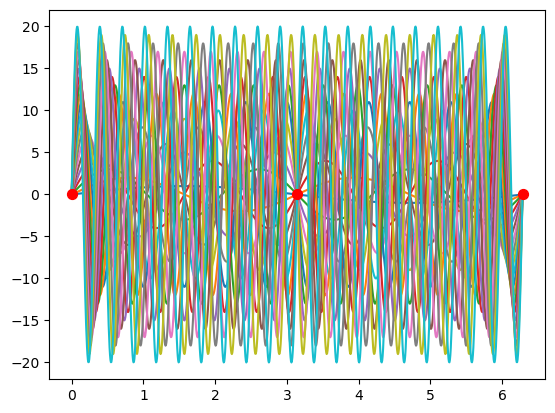

In [3]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); 
for i in range(20) :
    y = (i+1)*np.sin((i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi], [0, 0, 0], s=50, c="r", zorder=3)

Hay tanta incertidumbre que decides pedir más información y te dan otro punto.

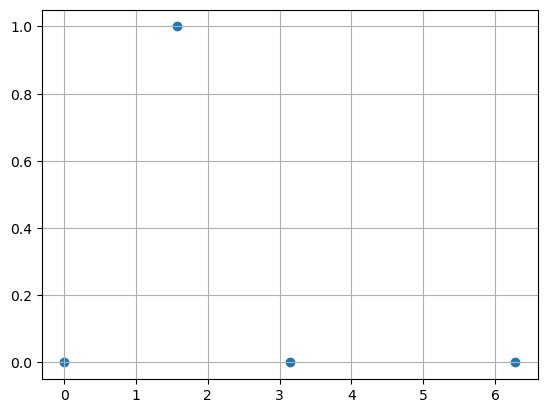

In [4]:
plt.figure(); plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1]); plt.grid()

Con esta nueva información actualizas tus creencias y reduces la cantidad de formas en las que se conectan estos puntos (siguen siendo infinitas).

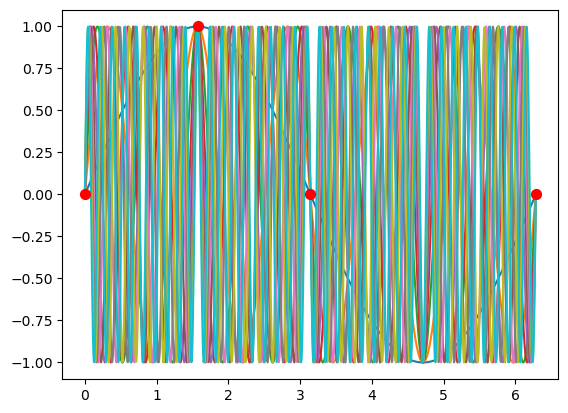

In [5]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); 
for i in range(10) :
    y = np.sin((4*i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1], s=50, c="r", zorder=3)

Te pones a pensar: "Sí. Teóricamente hay infinitas funciones que pueden conectar estos puntos, pero sólo algunas tienen sentido dado mi contexto."

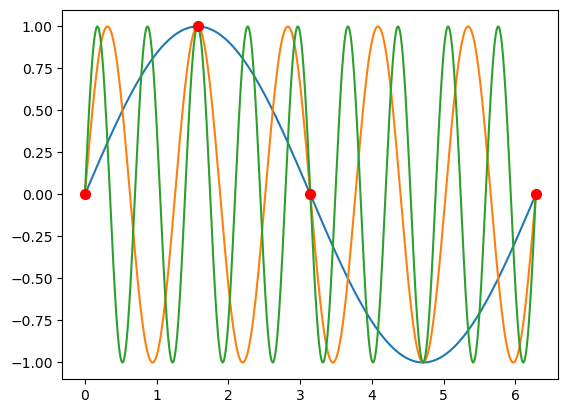

In [6]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); 
for i in range(3) :
    y = np.sin((4*i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1], s=50, c="r", zorder=3)

Ahora sólo quedan algunos pocos candidatos dado el criterio que tienes. Hay incertidumbre sobre cuál de estos candidatos podría ser el que mejor se ajusta, así que decides pedir más información. ¿Qué información serviría más?
- Se podría pedir el valor de $y$ cuando $x=\frac{3\pi}{2}$, pero los candidatos que tenemos todos pasan por el mismo punto. Incluso si nos dieran la información, no ayudaría de mucho.
- Se podría pedir fuera del rango que tenemos, pero quizás la información no existe o dado el contexto del problema es imposible que estos puntos existan.

Nos asignan nuestro último punto.

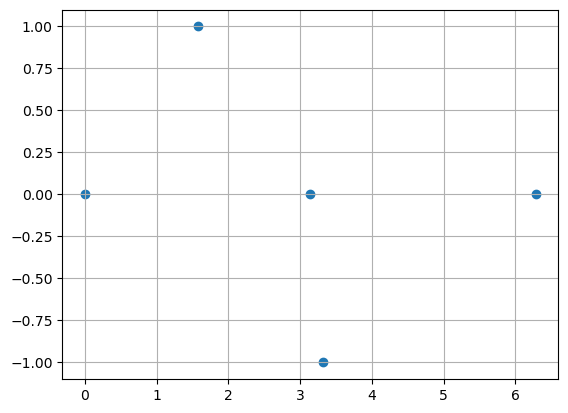

In [7]:
plt.figure(); plt.scatter([0, np.pi, 2*np.pi, np.pi/2, 19*np.pi/18], [0, 0, 0, 1, -1]); plt.grid()

Usamos esta nueva información (evidencia) junto con lo que conocíamos (anterior) y lo que creemos que es posible (verosimilitud) para decidir sobre una nueva función (posterior).

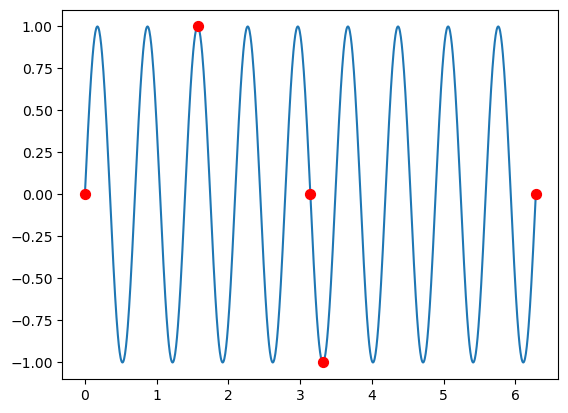

In [8]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); y = np.sin(9*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2, 19*np.pi/18], [0, 0, 0, 1, -1], s=50, c="r", zorder=3)

Una forma de realizar este experimento es mediante un proceso gaussiano, que asume que la variable de salida es una variable aleatoria con distribución normal multivariada. Utilicemos la función que encontramos y asumamos que no sabemos cuál es.

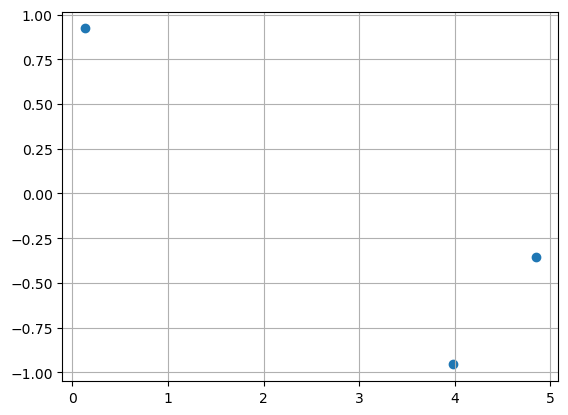

In [9]:
np.random.seed(10)
def f(x) :
    return np.sin(9*x)
X = np.random.uniform(0, 2*np.pi, 3).reshape([-1, 1])
plt.figure(); plt.scatter(X, f(X)); plt.grid()

Realizamos una regresión de proceso gaussiano para encontrar distribuciones que podrían darnos estas muestras

In [10]:
y = f(X).ravel()

In [11]:
kernel = 1.0 * RBF(length_scale=1.0)

In [12]:
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

In [13]:
gp.fit(X, y)

GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1),
                         n_restarts_optimizer=10)

Creamos un vector de valores posibles de $x$ y predecimos $y$ usando el resultado de la regresión.

In [14]:
X_pred = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)

In [15]:
y_pred, sigma = gp.predict(X_pred, return_std=True)

Graficamos nuestra primera propuesta, utilizando el error estándar para dibujar nuestros intervalos de confianza.

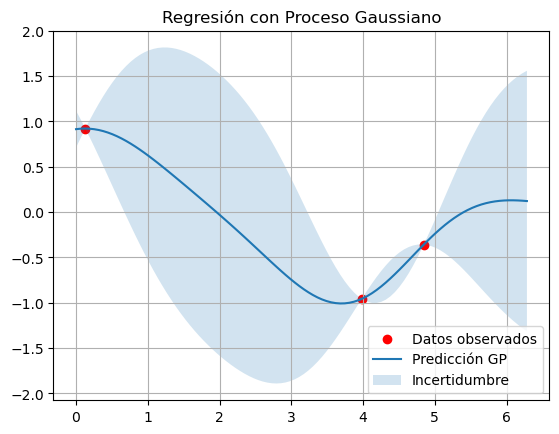

In [16]:
plt.figure()
plt.scatter(X, y, color='red', label='Datos observados')
plt.plot(X_pred, y_pred, label='Predicción GP')
plt.fill_between(
    X_pred.ravel(),
    y_pred - 2 * sigma,
    y_pred + 2 * sigma,
    alpha=0.2,
    label='Incertidumbre'
)
plt.legend()
plt.grid()
plt.title("Regresión con Proceso Gaussiano")
plt.show()

Podemos ver que necesitamos más muestras debido a que hay mucha incertidumbre en algunas partes de nuestro dominio. Hay varios criterios para decidir cómo pedir muestras:
- Maximizar (busco mi predicción del máximo actual y pido esa medida)
- Minimizar (busco mi predicción del mínimo actual y pido esa medida)
- Reducir incertidumbre (busco el punto donde mi intervalo de confianza es más grande y pido esa medida)

In [17]:
x_max = np.argmax(y_pred + 2*sigma)
x_min = np.argmin(y_pred)
x_inc = np.argmax(sigma)

In [18]:
print("Maximización:", X_pred[x_max])
print("Minimización:", X_pred[x_min])
print("Incertidumbre:", X_pred[x_inc])

Maximización: [1.20586385]
Minimización: [3.68105806]
Incertidumbre: [1.96746207]


Y repetimos el proceso ya con nueva información.

In [19]:
xnew = X_pred[x_inc]
ynew = f(xnew)

In [20]:
print(x_inc, X_pred[x_inc])

31 [1.96746207]


In [21]:
X = np.vstack((X, xnew))
y = np.append(y, ynew)

In [22]:
gp.fit(X, y)

GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1),
                         n_restarts_optimizer=10)

In [23]:
y_pred, sigma = gp.predict(X_pred, return_std=True)

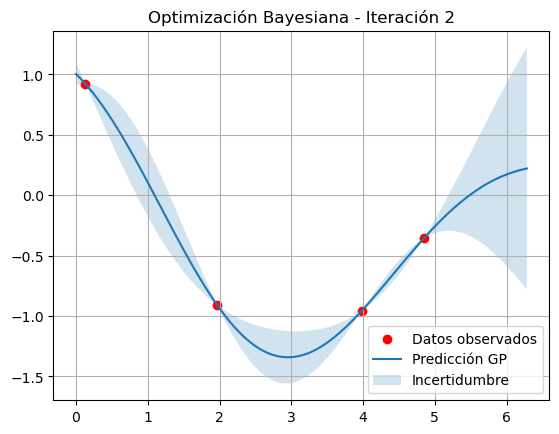

In [25]:
plt.figure()

plt.scatter(X, y, color='red', label='Datos observados')
plt.plot(X_pred, y_pred, label='Predicción GP')

plt.fill_between(
    X_pred.ravel(),
    y_pred - 2 * sigma,
    y_pred + 2 * sigma,
    alpha=0.2,
    label='Incertidumbre'
)

plt.legend()
plt.grid()
plt.title("Optimización Bayesiana - Iteración 2")
plt.show()

Se observa que el nuevo punto seleccionado se ubica en una región con alta incertidumbre (extremo del dominio). Esto indica que el modelo prioriza la exploración de zonas poco observadas. Tras incorporar esta nueva información, la incertidumbre disminuye localmente, mejorando la precisión del modelo en esa región. 

Repitamos el proceso 30 veces con una función distinta.

$$ f(x) = \sin{(\frac{x}{3})} + \cos{(2x)},\ \ \ \ x \in [-5\pi, 5\pi] $$

In [26]:
def f(x):
    return np.sin(x/3) + np.cos(2*x)

In [27]:
np.random.seed(10)
X = np.random.uniform(-5*np.pi, 5*np.pi, 3).reshape(-1,1)
y = f(X).ravel()

In [28]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

In [29]:
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1,1)).ravel()

In [30]:
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-3, 1e3))

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10
)

In [31]:
gp.fit(X_scaled, y_scaled)

GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1),
                         n_restarts_optimizer=10)

In [32]:
X_pred = np.linspace(-5*np.pi, 5*np.pi, 500).reshape(-1,1)

for i in range(30):
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.reshape(-1,1)).ravel()
    gp.fit(X_scaled, y_scaled)
    X_pred_scaled = scaler_X.transform(X_pred)
    y_pred_scaled, sigma = gp.predict(X_pred_scaled, return_std=True)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
    sigma = sigma * scaler_y.scale_
    i_max = np.argmax(y_pred + 2*sigma)
    x_new = X_pred[i_max]
    y_new = f(x_new)
    X = np.vstack((X, x_new))
    y = np.append(y, y_new)

C:\Users\valer\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\valer\anaconda3\Lib\s

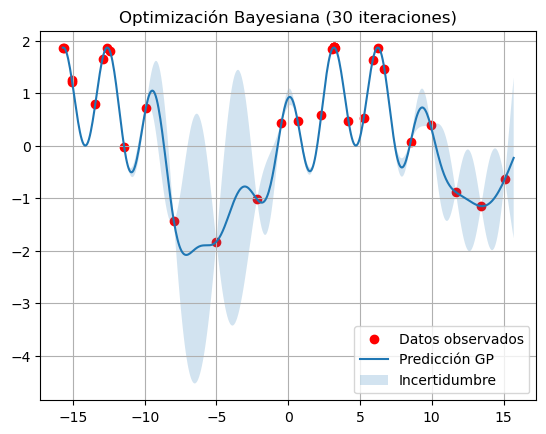

In [33]:
plt.figure()

plt.scatter(X, y, color='red', label='Datos observados')
plt.plot(X_pred, y_pred, label='Predicción GP')

plt.fill_between(
    X_pred.ravel(),
    y_pred - 2*sigma,
    y_pred + 2*sigma,
    alpha=0.2,
    label='Incertidumbre'
)

plt.legend()
plt.grid()
plt.title("Optimización Bayesiana (30 iteraciones)")
plt.show()

### Interpretación 

Después de 30 iteraciones, se observa que el modelo ha reducido significativamente la incertidumbre en gran parte del dominio. Los puntos muestreados se concentran en regiones donde la función presenta mayor variabilidad o donde el modelo tenía mayor incertidumbre.

El uso del criterio de maximización permite balancear exploración y explotación, logrando una mejor aproximación de la función real. A medida que se agregan más datos, el modelo mejora su precisión y la incertidumbre disminuye progresivamente.

### Actividad

1. Modificar el comportamiento de selección para elegir el máximo de las predicciones como el siguiente punto.
2. Modificar el comportamiento de selección para elegir el mínimo de las predicciones como el siguiente punto.

**Caso 1**

In [51]:
X1 = X.copy()
y1 = y.copy()
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-3, 1e3))
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10
)

In [52]:
X_pred = np.linspace(-5*np.pi, 5*np.pi, 500).reshape(-1,1)

for i in range(30):
    X_scaled = scaler_X.fit_transform(X1)
    y_scaled = scaler_y.fit_transform(y1.reshape(-1,1)).ravel()
    gp.fit(X_scaled, y_scaled)
    X_pred_scaled = scaler_X.transform(X_pred)
    y_pred_scaled, sigma = gp.predict(X_pred_scaled, return_std=True)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
    sigma = sigma * scaler_y.scale_
    i_next = np.argmax(y_pred)
    x_new = X_pred[i_next]
    y_new = f(x_new)
    X1 = np.vstack((X1, x_new))
    y1 = np.append(y1, y_new)

C:\Users\valer\anaconda3\Lib\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C

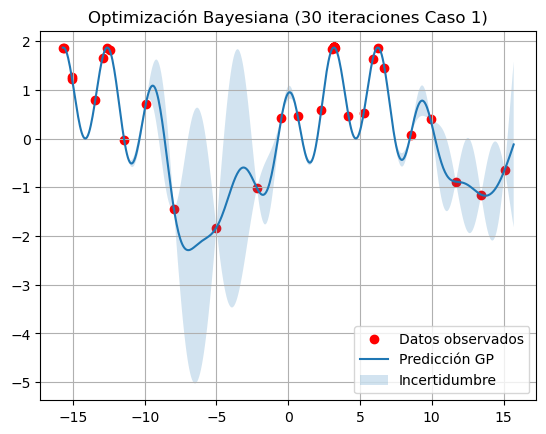

In [53]:
plt.figure()

plt.scatter(X1, y1, color='red', label='Datos observados')
plt.plot(X_pred, y_pred, label='Predicción GP')

plt.fill_between(
    X_pred.ravel(),
    y_pred - 2*sigma,
    y_pred + 2*sigma,
    alpha=0.2,
    label='Incertidumbre'
)

plt.legend()
plt.grid()
plt.title("Optimización Bayesiana (30 iteraciones Caso 1)")
plt.show()

**Caso 2**

In [54]:
X2 = X.copy()
y2 = y.copy()
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-3, 1e3))
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10
)

In [55]:
X_pred = np.linspace(-5*np.pi, 5*np.pi, 500).reshape(-1,1)

for i in range(30):
    X_scaled = scaler_X.fit_transform(X2)
    y_scaled = scaler_y.fit_transform(y2.reshape(-1,1)).ravel()
    gp.fit(X_scaled, y_scaled)
    X_pred_scaled = scaler_X.transform(X_pred)
    y_pred_scaled, sigma = gp.predict(X_pred_scaled, return_std=True)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
    sigma = sigma * scaler_y.scale_
    i_next = np.argmin(y_pred)
    x_new = X_pred[i_next]
    y_new = f(x_new)
    X2 = np.vstack((X2, x_new))
    y2 = np.append(y2, y_new)

C:\Users\valer\anaconda3\Lib\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\valer\anaconda3\Lib\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C

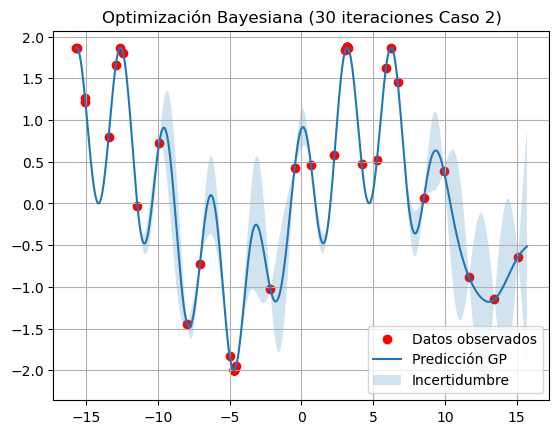

In [56]:
plt.figure()

plt.scatter(X2, y2, color='red', label='Datos observados')
plt.plot(X_pred, y_pred, label='Predicción GP')

plt.fill_between(
    X_pred.ravel(),
    y_pred - 2*sigma,
    y_pred + 2*sigma,
    alpha=0.2,
    label='Incertidumbre'
)

plt.legend()
plt.grid()
plt.title("Optimización Bayesiana (30 iteraciones Caso 2)")
plt.show()

### Interpretación

Al comparar ambos casos, se observa que el criterio de selección influye directamente en el comportamiento del muestreo. En el Caso 1, los puntos se concentran en los máximos de la función, mientras que en el Caso 2 se puede observar cómo se concentran en los mínimos. 

Esto muestra cómo la optimización basada únicamente en la predicción del modelo prioriza la explotación, lo que puede limitar la exploración de otras regiones del dominio. En contraste, métodos que incorporan incertidumbre permiten un balance más adecuado entre exploración y explotación.
_______________

## Conclusión

A lo largo de este notebook se exploró el funcionamiento de la regresión con procesos gaussianos y su aplicación en optimización bayesiana. Inicialmente, se mostró que con pocos puntos existen infinitas funciones que pueden ajustarse a los datos, lo que genera alta incertidumbre. Conforme se agregan nuevas observaciones, el modelo actualiza sus creencias, reduciendo dicha incertidumbre y mejorando la aproximación de la función real.

Posteriormente, se implementó un proceso iterativo en el que se seleccionan nuevos puntos con base en distintos criterios. Se analizó el caso de exploración (incertidumbre), así como dos estrategias de explotación: maximización y minimización. Se observó que el criterio de selección influye directamente en el comportamiento del muestreo: al maximizar, los puntos se concentran en los picos de la función, mientras que al minimizar se concentran en los valles. Esto demuestra la importancia de balancear exploración y explotación en problemas de optimización.

Además, se repitió el proceso múltiples veces sobre una función más compleja, lo que permitió observar cómo el modelo mejora progresivamente su predicción y reduce la incertidumbre en distintas regiones del dominio.

En cuanto al kernel, se utilizó una combinación de una constante y un kernel RBF (Radial Basis Function). Este kernel permite modelar funciones suaves, donde puntos cercanos en el dominio tienen valores similares. La constante controla la amplitud de la función, mientras que el RBF determina la suavidad mediante el parámetro de escala. Al eliminar los rangos de optimización y fijar los parámetros (por ejemplo, usando C(1.0) * RBF(1.0)), el modelo pierde flexibilidad, ya que no puede adaptarse automáticamente a la estructura de los datos. Esto puede resultar en una aproximación menos precisa y una representación menos realista de la incertidumbre.

En conclusión, los procesos gaussianos son una herramienta poderosa para modelar funciones desconocidas y cuantificar la incertidumbre. Su combinación con estrategias de selección de puntos permite implementar optimización bayesiana de manera eficiente, donde el kernel juega un papel fundamental al definir la capacidad del modelo para adaptarse a los datos.